# Optional Google Drive mount

In [ ]:
import os, sys, subprocess, warnings
warnings.filterwarnings('ignore')

# Install tensorboard if missing
try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorboard"])
    from torch.utils.tensorboard import SummaryWriter

In [ ]:
USE_DRIVE = True
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/ntc_project'
    USE_DRIVE = True
    print('Google Drive mounted. Files saved to', BASE_DIR)
except:
    BASE_DIR = '.'
    print('Running locally. Files saved to current directory.')

for sub in ['checkpoints', 'logs', 'exports', 'data', 'tensorboard']:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Files saved to /content/drive/MyDrive/ntc_project


# Imports

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt, math, json, pickle
from PIL import Image
from pathlib import Path
from datetime import datetime
import requests, tarfile, time
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}, VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4, VRAM: 15.6 GB


# Configs

In [ ]:
class Config:
    # Lean architecture
    BASE_RESOLUTION = 16
    NUM_LEVELS = 4
    LATENT_CHANNELS_LIST = [2, 2, 2, 1]   # per-level channels
    MLP_HIDDEN = 48                       # smaller hidden layer

    # Training
    BATCH_SIZE = 32768
    NUM_ITERATIONS = 10000        # a few more steps for convergence
    LEARNING_RATE = 0.01
    GRID_LR_MULTIPLIER = 10.0
    LR_STEP = 2000
    LR_GAMMA = 0.5
    GRAD_CLIP = 1.0

    # Progressive quantization
    QUANT_BITS = 8
    QUANT_RANGE = (-2.0, 2.0)
    QUANT_START_FRAC = 0.2       # no quant for first 20%
    QUANT_END_FRAC = 0.6         # full quant by 60%

    # Data
    TEXTURE_SIZE = 256
    NUM_TEXTURES = 1
    OUTPUT_CHANNELS = 3

    # Logging
    LOG_INTERVAL = 100
    CHECKPOINT_INTERVAL = 500
    VAL_VIS = 4

    @property
    def input_dim(self):
        return self.NUM_LEVELS * self.LATENT_CHANNELS

    @property
    def input_dim(self):
        return sum(self.LATENT_CHANNELS_LIST)

config = Config()
print(f'Latent dim: {config.input_dim}, Textures: {config.NUM_TEXTURES}')

Latent dim: 7, Textures: 1


# Download Dataset

Loading textures:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded 1 textures, shape torch.Size([1, 256, 256, 3])


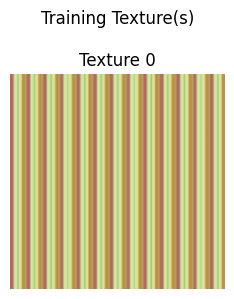

In [4]:
class DTDTextureDataset:
    DTD_URL = "https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz"

    def __init__(self, root, size=256, max_textures=1):
        self.root = Path(root)
        self.size = size
        self.data_dir = self.root / 'dtd'
        if not self.data_dir.exists():
            self._download()
        paths = sorted((self.data_dir / 'images').rglob('*.jpg'))
        if max_textures:
            paths = paths[:max_textures]
        self.textures = []
        for p in tqdm(paths, desc='Loading textures'):
            img = Image.open(p).convert('RGB').resize((size, size), Image.LANCZOS)
            tensor = torch.from_numpy(np.array(img)).float() / 255.0
            self.textures.append(tensor.to(device))
        self.textures = torch.stack(self.textures)  # [N,H,W,C]
        print(f'Loaded {len(self.textures)} textures, shape {self.textures.shape}')

    def _download(self):
        max_retries = 3
        for attempt in range(max_retries):
            try:
                print(f'Downloading DTD (attempt {attempt+1}/{max_retries})...')
                r = requests.get(self.DTD_URL, stream=True, timeout=30)
                r.raise_for_status()
                tar = self.root / 'dtd.tar.gz'
                with open(tar, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
                print('Extracting...')
                import tarfile as tf
                with tf.open(tar, 'r:gz') as t:
                    t.extractall(path=self.root)
                os.remove(tar)
                print('Download complete.')
                return
            except Exception as e:
                print(f'Attempt {attempt+1} failed: {e}')
                if attempt < max_retries - 1:
                    print('Retrying in 5 seconds...')
                    time.sleep(5)
                else:
                    raise RuntimeError(f'Failed to download DTD after {max_retries} attempts.')

    def __len__(self):
        return len(self.textures)

    def get_random_samples(self, batch_size):
        N = len(self.textures)
        H, W, C = self.textures.shape[1], self.textures.shape[2], self.textures.shape[3]
        B = batch_size
        tex_idx = torch.randint(0, N, (B,), device=device)
        u = torch.rand(B, device=device)
        v = torch.rand(B, device=device)

        x = u * (W - 1)
        y = v * (H - 1)
        x0 = torch.floor(x).long().clamp(0, W-2)
        x1 = x0 + 1
        y0 = torch.floor(y).long().clamp(0, H-2)
        y1 = y0 + 1
        fx = x - x0.float()
        fy = y - y0.float()
        wa = ((1-fx)*(1-fy)).unsqueeze(-1)
        wb = ((1-fx)*fy).unsqueeze(-1)
        wc = (fx*(1-fy)).unsqueeze(-1)
        wd = (fx*fy).unsqueeze(-1)

        gt = torch.zeros(B, C, device=device)
        for i in range(N):
            mask = (tex_idx == i)
            n = mask.sum().item()
            if n == 0: continue
            idx = mask.nonzero(as_tuple=True)[0]
            tex = self.textures[i]
            Ia = tex[y0[idx], x0[idx], :]
            Ib = tex[y1[idx], x0[idx], :]
            Ic = tex[y0[idx], x1[idx], :]
            Id = tex[y1[idx], x1[idx], :]
            gt[idx] = (wa[idx]*Ia + wb[idx]*Ib + wc[idx]*Ic + wd[idx]*Id)
        return u, v, gt, tex_idx

# Initialize dataset
dataset = DTDTextureDataset(os.path.join(BASE_DIR, 'data'), config.TEXTURE_SIZE, config.NUM_TEXTURES)

# Show sample texture(s)
fig, axes = plt.subplots(1, min(config.NUM_TEXTURES, 4), figsize=(12, 3))
if config.NUM_TEXTURES == 1:
    axes = [axes]
for i in range(min(config.NUM_TEXTURES, 4)):
    axes[i].imshow(dataset.textures[i].cpu())
    axes[i].set_title(f'Texture {i}')
    axes[i].axis('off')
plt.suptitle('Training Texture(s)')
plt.tight_layout()
plt.show()

# Feature Pyramid

In [5]:
def hard_gelu(x):
    return x * torch.sigmoid(1.702 * x)

class NTCFeaturePyramid(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.levels = nn.ParameterList()
        for i in range(config.NUM_LEVELS):
            res = config.BASE_RESOLUTION * (2**i)
            ch = config.LATENT_CHANNELS_LIST[i]   # per-level channels
            self.levels.append(nn.Parameter(torch.randn(1, ch, res, res) * 0.5))

    def forward(self, u, v, quantize=False):
        feats = []
        for grid in self.levels:
            g = self._quantize(grid) if quantize else grid
            feats.append(self._bilinear(u, v, g))
        return torch.cat(feats, dim=-1)

    def _bilinear(self, u, v, grid):
        _, C, H, W = grid.shape
        g = grid.squeeze(0)
        x = u * (W - 1)
        y = v * (H - 1)
        x0 = torch.floor(x).long().clamp(0, W-2)
        x1 = x0 + 1
        y0 = torch.floor(y).long().clamp(0, H-2)
        y1 = y0 + 1
        fx = x - x0.float()
        fy = y - y0.float()
        Ia = g[:, y0, x0]
        Ib = g[:, y1, x0]
        Ic = g[:, y0, x1]
        Id = g[:, y1, x1]
        wa = (1-fx)*(1-fy)
        wb = (1-fx)*fy
        wc = fx*(1-fy)
        wd = fx*fy
        return (wa*Ia + wb*Ib + wc*Ic + wd*Id).T

    def _quantize(self, grid):
        lo, hi = config.QUANT_RANGE
        scale = (2**config.QUANT_BITS - 1) / (hi - lo)
        zp = -lo * scale
        q = torch.round(grid * scale + zp).clamp(0, 2**config.QUANT_BITS - 1)
        q = (q - zp) / scale
        return grid + (q - grid).detach()  # straight-through

class NTCDecoder(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, out_dim))

    def forward(self, x):
        for i, layer in enumerate(self.net):
            x = layer(x)
            if i < 2:
                x = hard_gelu(x)
        return x  # no sigmoid (learns full range)

class NTCCompressor(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.pyramid = NTCFeaturePyramid(config)
        self.decoder = NTCDecoder(config.input_dim, config.OUTPUT_CHANNELS, config.MLP_HIDDEN)

    def forward(self, u, v, quantize=True):
        return self.decoder(self.pyramid(u, v, quantize))

    def compression_ratio(self):
        orig = config.TEXTURE_SIZE**2 * config.OUTPUT_CHANNELS * 4  # FP32
        grid_bytes = sum(p.numel() for p in self.pyramid.parameters())  # 1 byte each after quant
        mlp_bytes = sum(p.numel() for p in self.decoder.parameters()) * 2  # FP16
        return orig / (grid_bytes + mlp_bytes)

model = NTCCompressor(config).to(device)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Expected compression ratio: {model.compression_ratio():.1f}x')

Total parameters: 30,019
Expected compression ratio: 23.9x


# Checkpoint Manager

In [6]:
class CheckpointManager:
    def __init__(self, dir):
        self.dir = Path(dir)
        self.dir.mkdir(parents=True, exist_ok=True)

    def save(self, model, opt, sched, it, loss_hist, name='ntc'):
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        path = self.dir / f'{name}_iter{it}_{ts}.pt'
        cfg = {k:v for k,v in Config.__dict__.items()
               if not k.startswith('_') and not callable(v) and not isinstance(v, property)}
        ckpt = {
            'iteration': it,
            'model_state': model.state_dict(),
            'optimizer_state': opt.state_dict(),
            'scheduler_state': sched.state_dict() if sched else None,
            'loss_history': loss_hist,
            'config': cfg
        }
        torch.save(ckpt, path)
        torch.save(ckpt, self.dir / f'{name}_latest.pt')
        print(f'Saved checkpoint: {path.name}')
        return path

    def load(self, name='ntc'):
        p = self.dir / f'{name}_latest.pt'
        if not p.exists():
            print('No checkpoint found.')
            return None
        ckpt = torch.load(p, map_location=device)
        print(f'Loaded checkpoint from iteration {ckpt["iteration"]}')
        return ckpt

ckpt_mgr = CheckpointManager(os.path.join(BASE_DIR, 'checkpoints'))

# Training setup

In [ ]:
optimizer = optim.Adam([
    {'params': model.pyramid.parameters(), 'lr': config.LEARNING_RATE * config.GRID_LR_MULTIPLIER},
    {'params': model.decoder.parameters(),  'lr': config.LEARNING_RATE}
])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=config.LR_STEP, gamma=config.LR_GAMMA)

# Resume if checkpoint exists
loaded = ckpt_mgr.load('ntc_dtd')
start_it = 0
loss_history = []
if loaded:
    model.load_state_dict(loaded['model_state'])
    optimizer.load_state_dict(loaded['optimizer_state'])
    scheduler.load_state_dict(loaded['scheduler_state'])
    start_it = loaded['iteration'] + 1
    loss_history = loaded['loss_history']
    print(f'Resuming from iteration {start_it}')
else:
    print('Starting fresh training.')

log_dir = os.path.join(BASE_DIR, 'tensorboard', datetime.now().strftime('%Y%m%d_%H%M%S'))
writer = SummaryWriter(log_dir)
print(f'TensorBoard: {log_dir}')

No checkpoint found.
Starting fresh training.
TensorBoard: /content/drive/MyDrive/ntc_project/tensorboard/20260513_164250


# Progressive Quantization Training Loop

In [ ]:
total_iters = config.NUM_ITERATIONS
quant_start = int(total_iters * config.QUANT_START_FRAC)
quant_end   = int(total_iters * config.QUANT_END_FRAC)

pbar = tqdm(range(start_it, total_iters), initial=start_it, total=total_iters, desc='Training')

for it in pbar:
    # ---- Quantization factor (0→1) ----
    if it < quant_start:
        quant_factor = 0.0
    elif it < quant_end:
        quant_factor = (it - quant_start) / (quant_end - quant_start)
    else:
        quant_factor = 1.0

    u, v, gt, _ = dataset.get_random_samples(config.BATCH_SIZE)

    # ---- Forward pass with blended quantization (no .data overwrite) ----
    # Get full-precision features
    features = model.pyramid(u, v, quantize=False)
    if quant_factor > 0:
        # Create quantized versions of grids (straight-through)
        blended_grids = []
        with torch.no_grad():
            for level in model.pyramid.levels:
                lo, hi = config.QUANT_RANGE
                scale = (2**config.QUANT_BITS - 1) / (hi - lo)
                zp = -lo * scale
                q = torch.round(level * scale + zp).clamp(0, 2**config.QUANT_BITS - 1)
                q = (q - zp) / scale
                # Blend original and quantized: gradient flows to original
                blended = level + (q - level).detach() * quant_factor
                blended_grids.append(blended)
        # Recompute features using blended grids
        features = torch.cat([model.pyramid._bilinear(u, v, g) for g in blended_grids], dim=-1)

    pred = model.decoder(features)
    loss = F.mse_loss(pred, gt)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if it % config.LOG_INTERVAL == 0:
        psnr = -10*math.log10(loss.item()) if loss.item()>0 else 100
        writer.add_scalar('Loss/train', loss.item(), it)
        writer.add_scalar('PSNR/train', psnr, it)
        pbar.set_postfix(loss=f'{loss.item():.4f}', PSNR=f'{psnr:.1f}dB',
                        quant=f'{quant_factor:.1f}', lr=f'{scheduler.get_last_lr()[0]:.2e}')

    if it % config.CHECKPOINT_INTERVAL == 0 and it > 0:
        ckpt_mgr.save(model, optimizer, scheduler, it, loss_history, 'ntc_dtd')
        # Quick validation visualization
        with torch.no_grad():
            tex = dataset.textures[0]  # show the first texture
            H, W = tex.shape[0], tex.shape[1]
            y, x = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
            ufull = (x.float()+0.5)/W; vfull = (y.float()+0.5)/H
            uf = ufull.reshape(-1); vf = vfull.reshape(-1)
            chunks = torch.split(torch.arange(H*W, device=device), 8192)
            recon = []
            for ch in chunks:
                recon.append(model(uf[ch], vf[ch], quantize=True))
            recon = torch.cat(recon).reshape(H, W, -1).clamp(0,1)
            mse = F.mse_loss(recon, tex).item()
            writer.add_scalar('Validation/MSE', mse, it)
            writer.add_image('Val/Original', tex.permute(2,0,1), it)
            writer.add_image('Val/Reconstructed', recon.permute(2,0,1), it)

writer.close()
ckpt_mgr.save(model, optimizer, scheduler, total_iters-1, loss_history, 'ntc_dtd_final')
print('Training complete.')

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved checkpoint: ntc_dtd_iter500_20260513_164256.pt
Saved checkpoint: ntc_dtd_iter1000_20260513_164301.pt
Saved checkpoint: ntc_dtd_iter1500_20260513_164305.pt
Saved checkpoint: ntc_dtd_iter2000_20260513_164311.pt
Saved checkpoint: ntc_dtd_iter2500_20260513_164315.pt
Saved checkpoint: ntc_dtd_iter3000_20260513_164319.pt
Saved checkpoint: ntc_dtd_iter3500_20260513_164323.pt
Saved checkpoint: ntc_dtd_iter4000_20260513_164327.pt
Saved checkpoint: ntc_dtd_iter4500_20260513_164331.pt
Saved checkpoint: ntc_dtd_iter5000_20260513_164335.pt
Saved checkpoint: ntc_dtd_iter5500_20260513_164340.pt
Saved checkpoint: ntc_dtd_iter6000_20260513_164344.pt
Saved checkpoint: ntc_dtd_iter6500_20260513_164348.pt
Saved checkpoint: ntc_dtd_iter7000_20260513_164353.pt
Saved checkpoint: ntc_dtd_iter7500_20260513_164357.pt
Saved checkpoint: ntc_dtd_iter8000_20260513_164400.pt
Saved checkpoint: ntc_dtd_iter8500_20260513_164405.pt
Saved checkpoint: ntc_dtd_iter9000_20260513_164412.pt
Saved checkpoint: ntc_dtd_ite

# Visualization of results

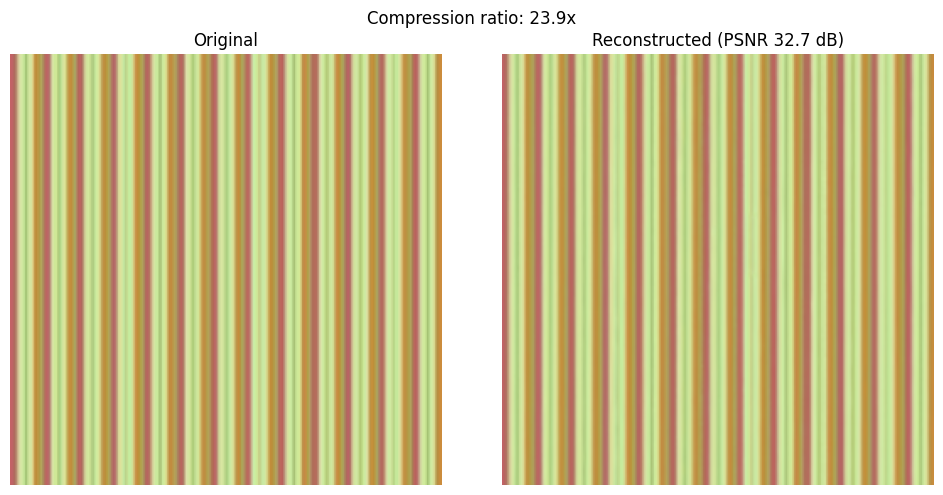

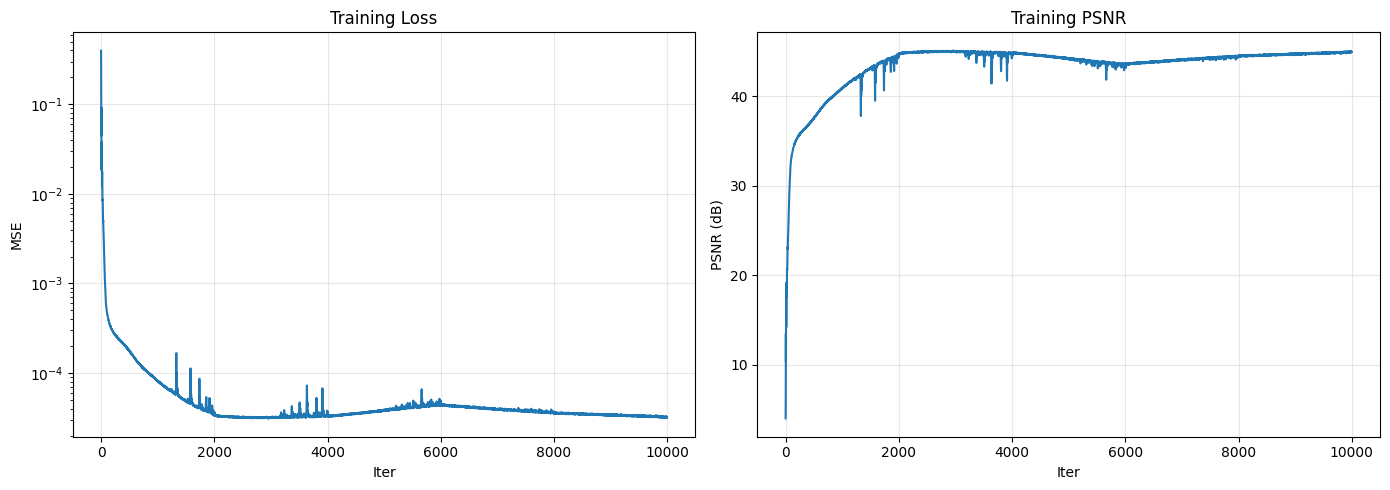

Final PSNR: 44.95 dB
Compression ratio: 23.9x


In [ ]:
def reconstruct_full(model, idx):
    tex = dataset.textures[idx]
    H, W = tex.shape[0], tex.shape[1]
    y, x = torch.meshgrid(torch.arange(H, device=device), torch.arange(W, device=device), indexing='ij')
    u = (x.float()+0.5)/W; v = (y.float()+0.5)/H
    uf = u.reshape(-1); vf = v.reshape(-1)
    chunks = torch.split(torch.arange(H*W, device=device), 8192)
    recon = []
    with torch.no_grad():
        for ch in chunks:
            recon.append(model(uf[ch], vf[ch], quantize=True))
    return torch.cat(recon).reshape(H, W, -1)

vis_idx = 0  # only one texture
orig = dataset.textures[vis_idx].cpu()
recon = reconstruct_full(model, vis_idx).cpu().clamp(0,1)
mse = F.mse_loss(recon, orig).item()
psnr = -10*math.log10(mse) if mse>0 else 100

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(orig); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(recon); axes[1].set_title(f'Reconstructed (PSNR {psnr:.1f} dB)'); axes[1].axis('off')
plt.suptitle(f'Compression ratio: {model.compression_ratio():.1f}x')
plt.tight_layout()
plt.show()

# Loss & PSNR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(loss_history)
ax1.set_yscale('log'); ax1.set_xlabel('Iter'); ax1.set_ylabel('MSE'); ax1.set_title('Training Loss'); ax1.grid(alpha=0.3)
psnr_hist = [-10*math.log10(l) if l>0 else 100 for l in loss_history]
ax2.plot(psnr_hist)
ax2.set_xlabel('Iter'); ax2.set_ylabel('PSNR (dB)'); ax2.set_title('Training PSNR'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final PSNR: {psnr_hist[-1]:.2f} dB')
print(f'Compression ratio: {model.compression_ratio():.1f}x')

# Export compressed model

In [ ]:
def export_model(model, config, dir):
    path = Path(dir)
    path.mkdir(parents=True, exist_ok=True)
    for i, level in enumerate(model.pyramid.levels):
        lo, hi = config.QUANT_RANGE
        scale = (2**config.QUANT_BITS - 1)/(hi - lo)
        zp = -lo * scale
        q = torch.round(level.data * scale + zp).clamp(0, 2**config.QUANT_BITS - 1)
        np.save(path / f'grid_{i}.npy', q.squeeze(0).cpu().numpy().astype(np.uint8))
    mlp = {k:v.half().cpu().detach().numpy() for k,v in model.decoder.state_dict().items()}
    with open(path / 'mlp.pkl', 'wb') as f:
        pickle.dump(mlp, f)
    meta = {
        'num_levels': config.NUM_LEVELS,
        'base_res': config.BASE_RESOLUTION,
        'latent_channels': config.input_dim,
        'output_channels': config.OUTPUT_CHANNELS,
        'mlp_hidden': config.MLP_HIDDEN,
        'texture_size': config.TEXTURE_SIZE
    }
    with open(path / 'metadata.json', 'w') as f:
        json.dump(meta, f, indent=2)
    total = sum(p.numel() for p in model.pyramid.parameters()) + sum(p.numel() for p in model.decoder.parameters())*2
    print(f'Exported to {path} ({total/1024:.1f} KB)')

export_model(model, config, os.path.join(BASE_DIR, 'exports'))

Exported to /content/drive/MyDrive/ntc_project/exports (32.1 KB)
